In [2]:
import pandas as pd
import wandb
from scipy import stats

wandb.login(key="cf344975eb80edf6f0d52af80528cc6094234caf")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/rahul/.netrc
wandb: Currently logged in as: rahul-e-dev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
api = wandb.Api()
runs = api.runs("rahul-e-dev/evaluate_all")

In [7]:
a = runs[0]

In [13]:
a.tags

['baseline', 'scaffold', 'single_target_tba']

In [2]:
def load_run(run_name):
    api = wandb.Api()
    runs = api.runs("rahul-e-dev/evaluate_all")
    run = next(run for run in runs if run.name == run_name)
    
    cols = [
        # 'outer', 
        # 'inner', 
        'average_precision', 
        'roc_auc',
        'accuracy', 
        'balanced_accuracy', 
        'precision', 
        'recall',
        'f1', 
        'mcc',
    ]

    df = pd.DataFrame.from_records(list(run.scan_history()))
    df = df.loc[:, cols]
    return df

In [52]:
baseline_df = load_run("skilled-thunder-81")
deltaprop_df = load_run("solar-disco-82")

In [53]:
baseline_df["method"] = "baseline"
deltaprop_df["method"] = "deltaprop"

baseline_df = baseline_df.reset_index(names=["cv_cycle"])
deltaprop_df = deltaprop_df.reset_index(names=["cv_cycle"])

In [54]:
fin_df = pd.concat([baseline_df, deltaprop_df])
fin_df["split"] = "scaffold"

In [55]:
metric_ls = [
    'average_precision', 
    'roc_auc',
    # 'accuracy', 
    # 'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
]

In [56]:
for metric in metric_ls:
    groups = fin_df.groupby('method')[metric].apply(list)
    stat, pvalue = stats.levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

Levene test for average_precision: p-value = 0.6417971088996831
Levene test for roc_auc: p-value = 0.8914512908578824
Levene test for precision: p-value = 0.8371808726835076
Levene test for recall: p-value = 0.03514834010380082
Levene test for f1: p-value = 0.28654458209693123
Levene test for mcc: p-value = 0.12947390829581895


In [57]:
variances_by_method = fin_df.groupby('method')[metric_ls].var()
max_fold_diff = variances_by_method.max() / variances_by_method.min()
print(max_fold_diff)

average_precision    1.095163
roc_auc              1.126928
precision            1.620402
recall               2.685618
f1                   1.523974
mcc                  2.061863
dtype: float64


In [58]:
from stats_utils import (
    make_boxplots_nonparametric,
    make_boxplots_parametric,
    make_ci_plot_grid,
    make_mcs_plot_grid,
    make_normality_diagnostic,
    rm_tukey_hsd,
)

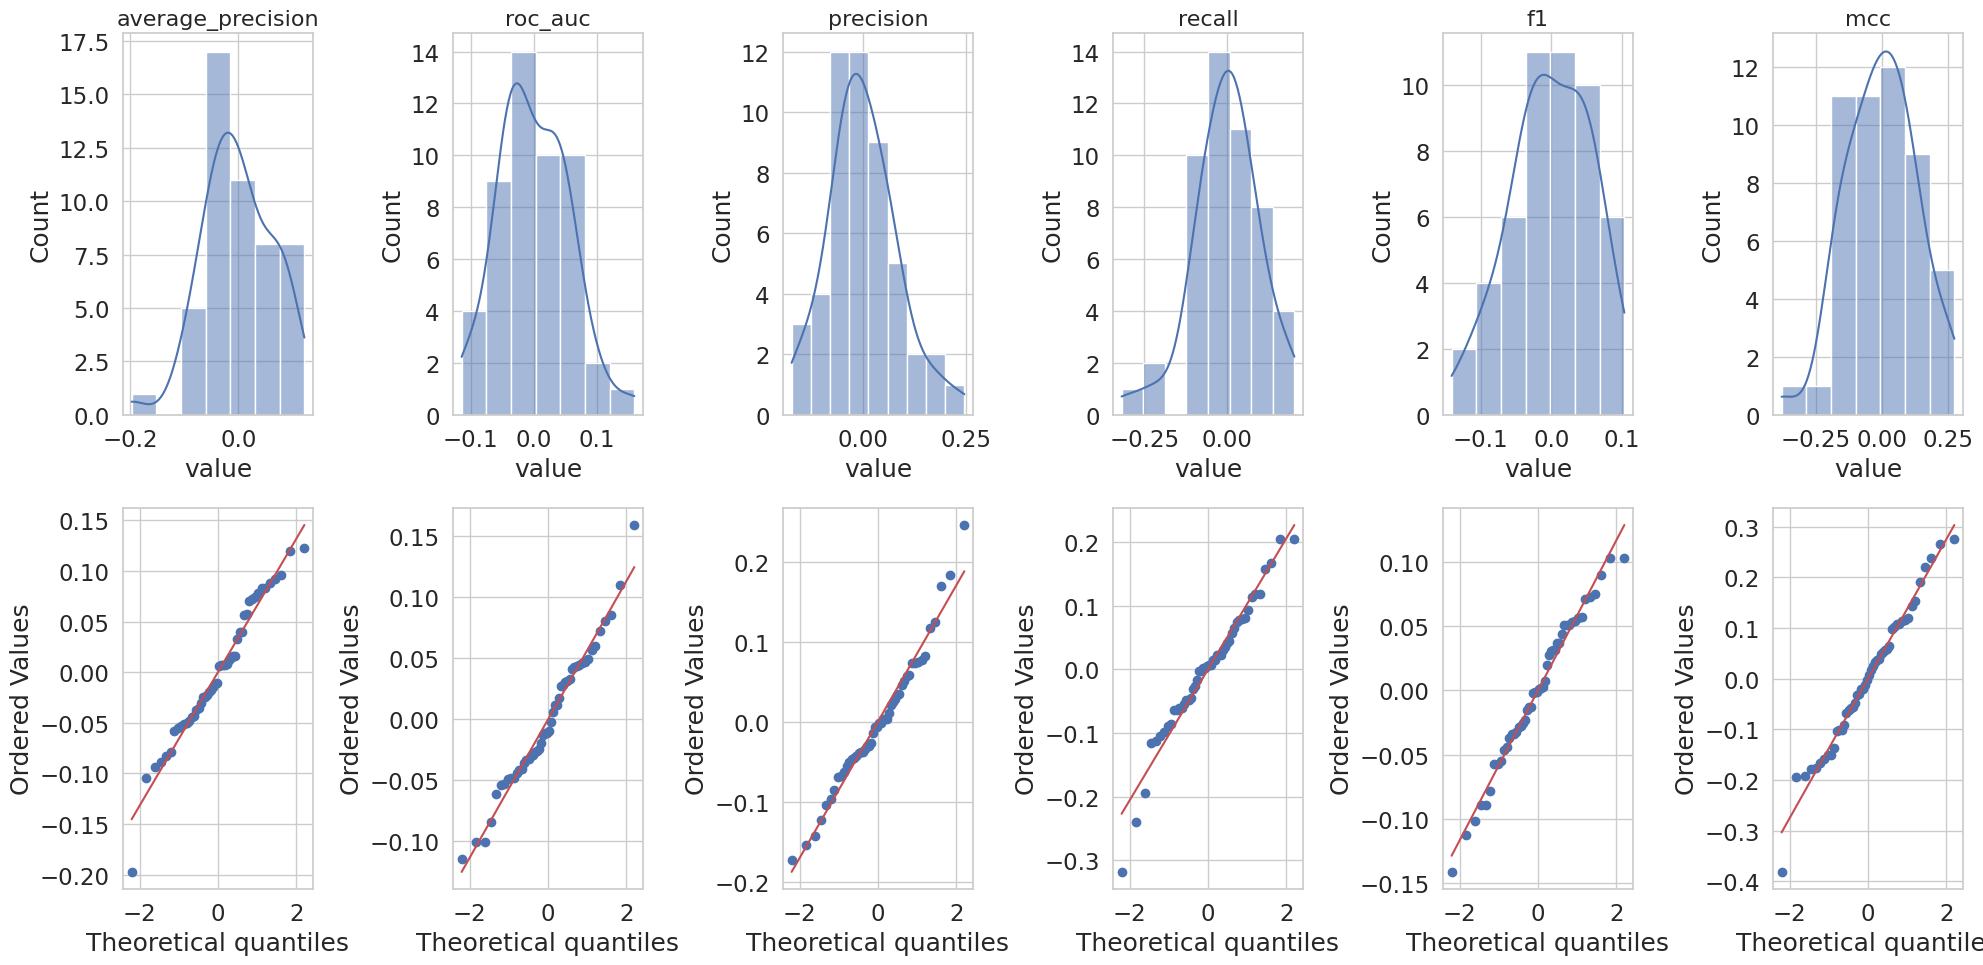

In [59]:
make_normality_diagnostic(fin_df.copy(), metric_ls)

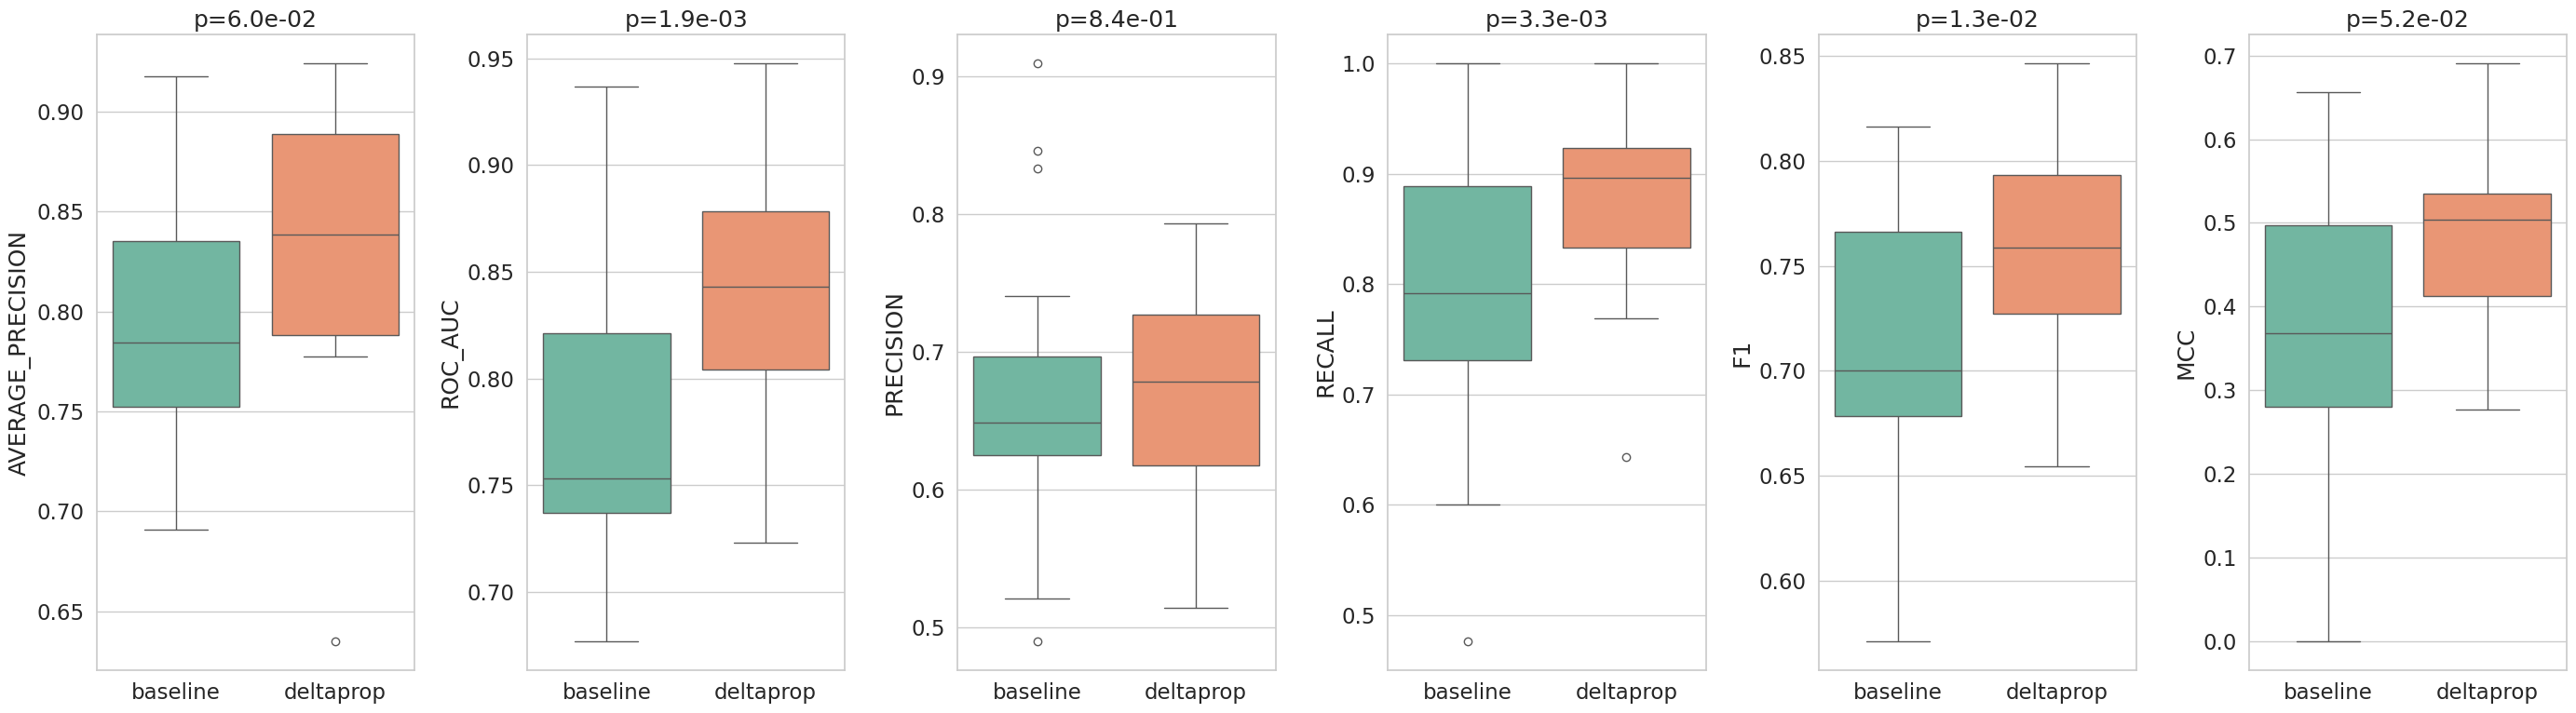

In [60]:
make_boxplots_parametric(fin_df.copy(), metric_ls)

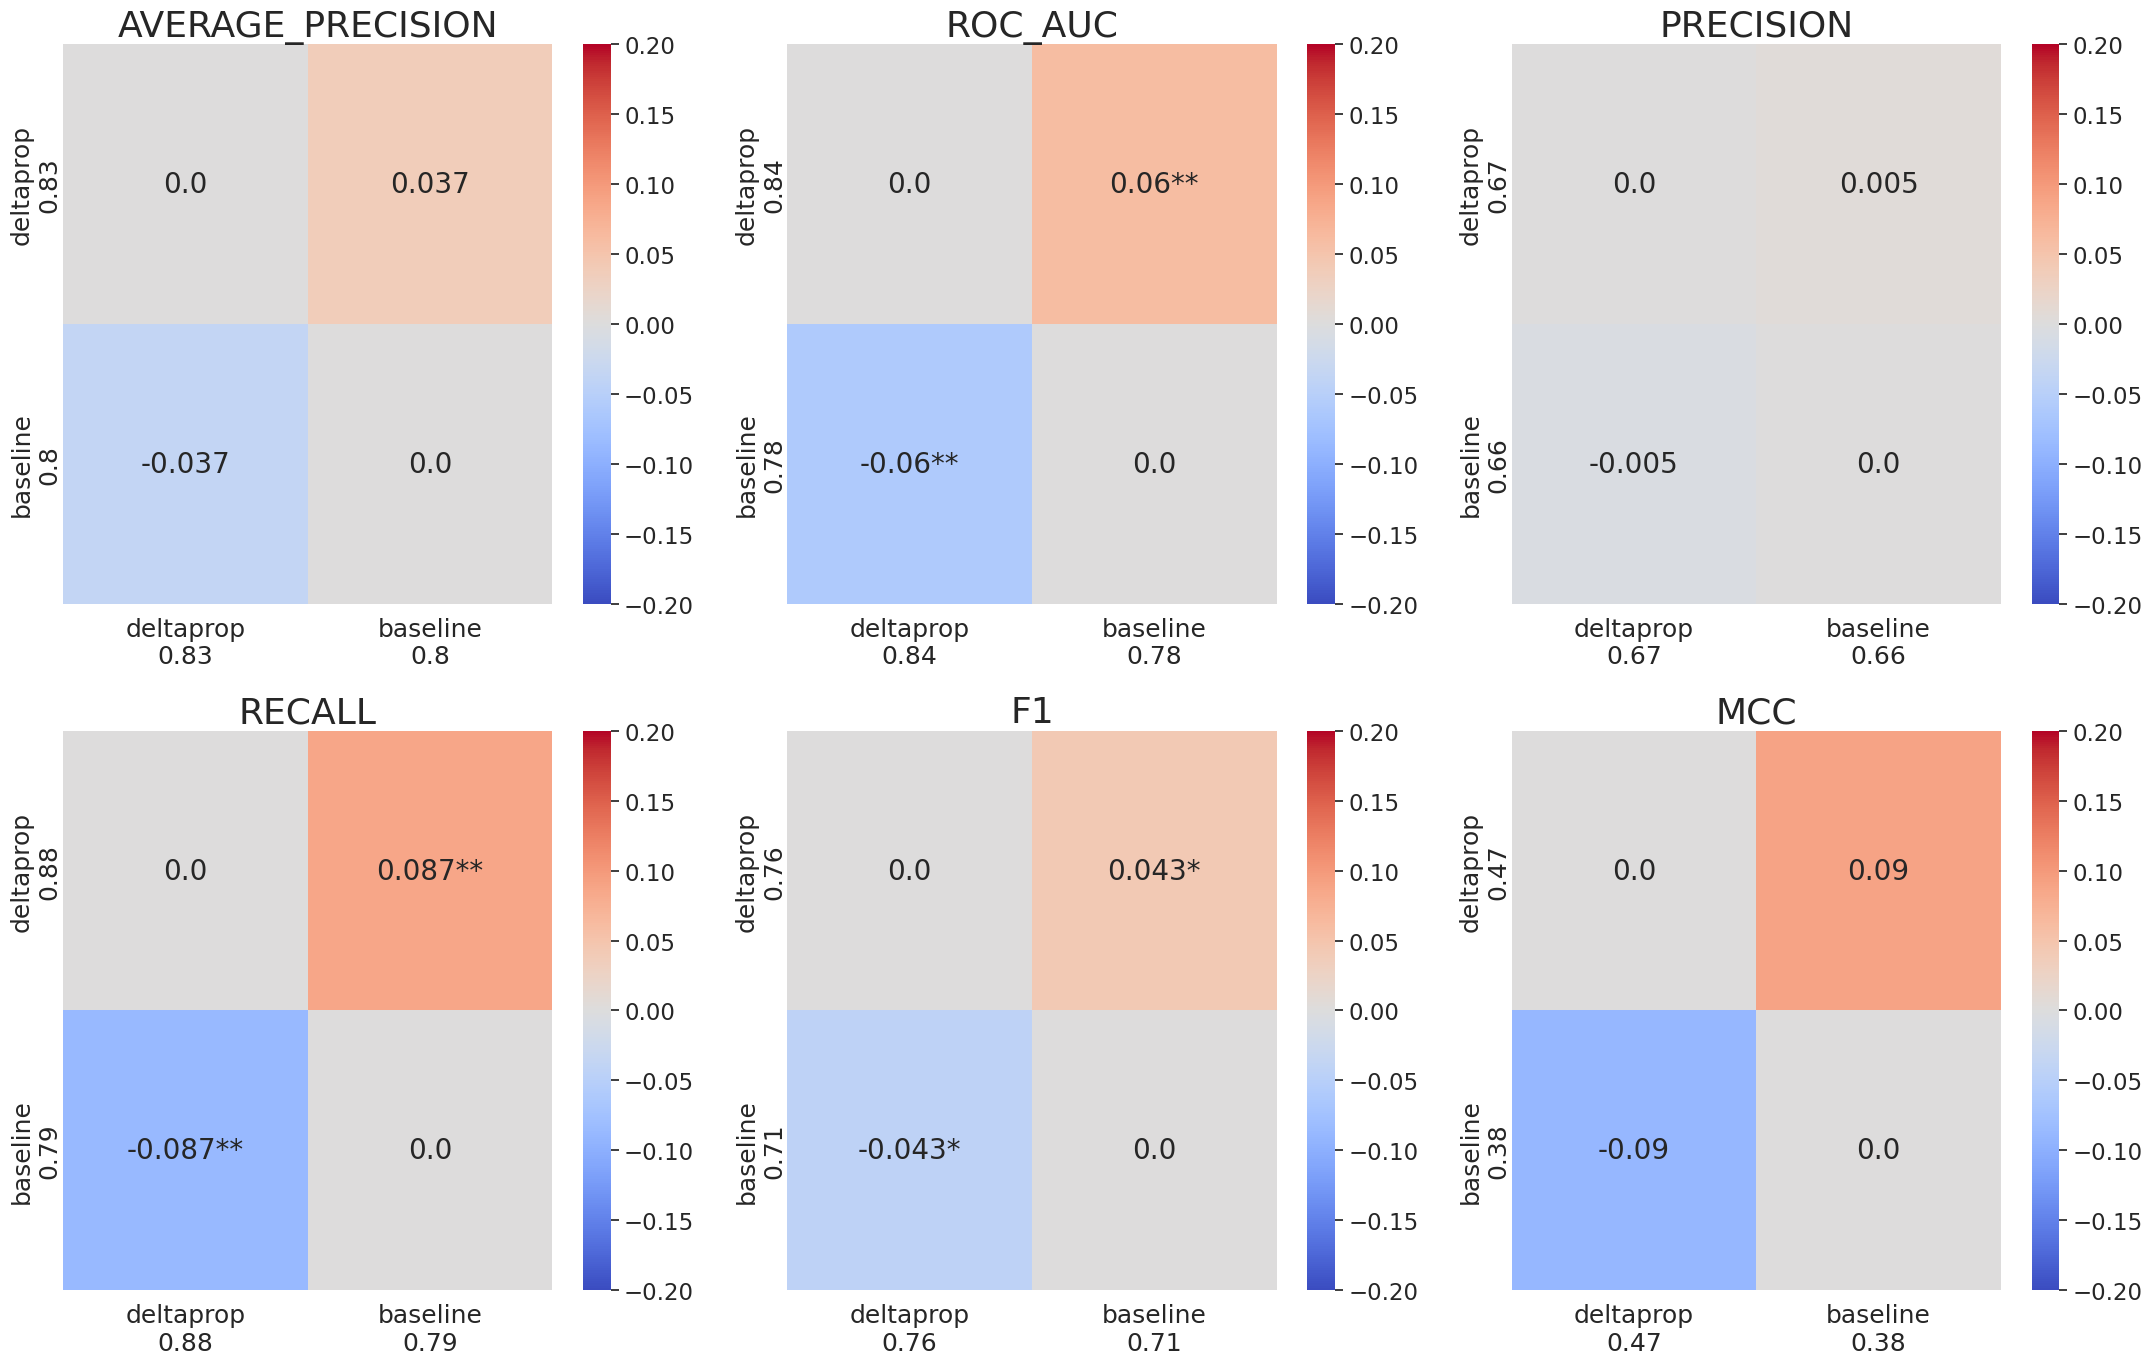

In [61]:
effect_dict = {m: 0.1 for m in metric_ls}
direction_dict = {m: "maximize" for m in metric_ls} 

make_mcs_plot_grid(fin_df, metric_ls, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(22, 14), cell_text_size=20, axis_text_size=18, title_text_size=26, show_diff=True, sort_axes=True)

In [62]:
for i, metric in enumerate(metric_ls):
    df_tukey, _, _, _ = rm_tukey_hsd(fin_df, metric, group_col="method")
    print(df_tukey)

                        group1     group2  meandiff     lower     upper  \
baseline - deltaprop  baseline  deltaprop -0.037232 -0.076196  0.001732   

                         p-adj  group1_mean  group2_mean  
baseline - deltaprop  0.060225     0.795191     0.832423  
                        group1     group2  meandiff     lower     upper  \
baseline - deltaprop  baseline  deltaprop -0.060052 -0.095583 -0.024522   

                         p-adj  group1_mean  group2_mean  
baseline - deltaprop  0.001896     0.777112     0.837164  
                        group1     group2 meandiff     lower     upper  \
baseline - deltaprop  baseline  deltaprop -0.00501 -0.056679  0.046658   

                         p-adj  group1_mean  group2_mean  
baseline - deltaprop  0.847559     0.663425     0.668436  
                        group1     group2  meandiff     lower     upper  \
baseline - deltaprop  baseline  deltaprop -0.087366 -0.142638 -0.032093   

                         p-adj  group1_mean 

In [63]:
df_tukey

,group1,group2,meandiff,lower,upper,p-adj,group1_mean,group2_mean
baseline - deltaprop,baseline,deltaprop,-0.089569,-0.180039,0.000901,0.052146,0.381098,0.470667


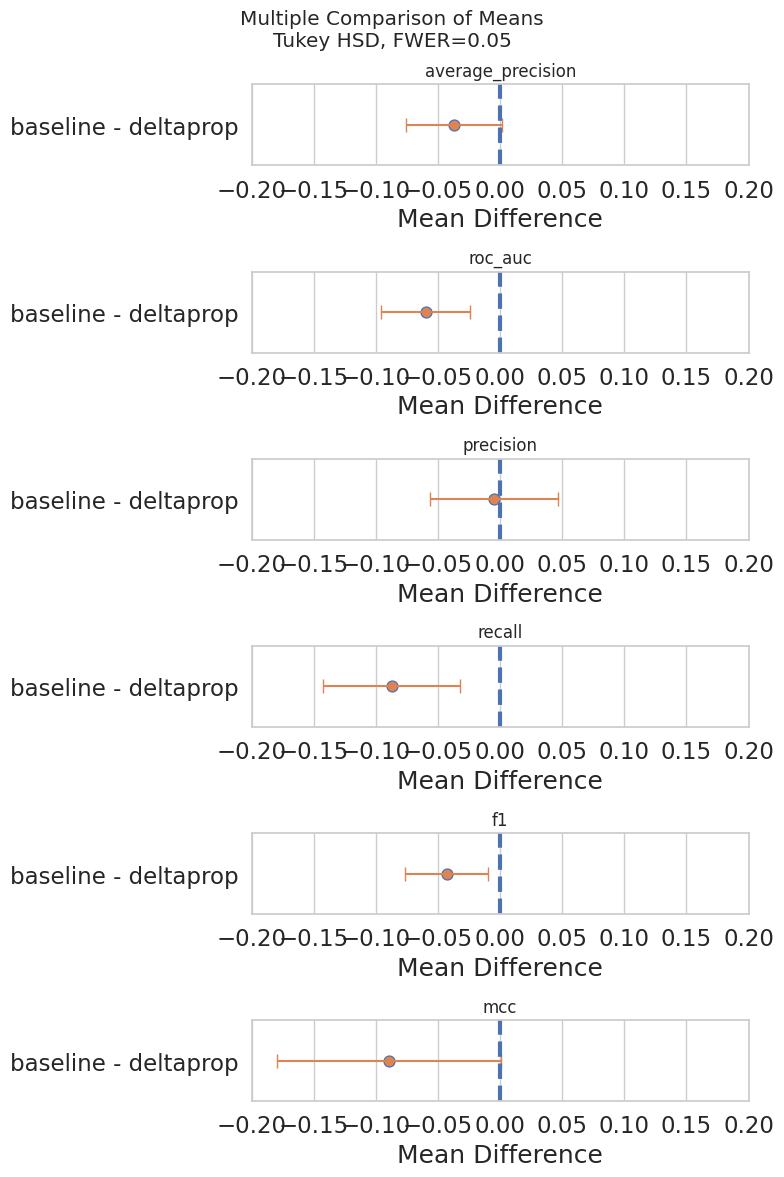

In [64]:
make_ci_plot_grid(fin_df, metric_ls, "method")

In [1]:
import pandas as pd
import pingouin as pg

df = pd.DataFrame({
    'white': {0: 10, 1: 8, 2: 7, 3: 9, 4: 7, 5: 4, 6: 5, 7: 6, 8: 5, 9: 10, 10: 4, 11: 7},
    'red': {0: 7, 1: 5, 2: 8, 3: 6, 4: 5, 5: 7, 6: 9, 7: 6, 8: 4, 9: 6, 10: 7, 11: 3},
    'rose': {0: 8, 1: 5, 2: 6, 3: 4, 4: 7, 5: 5, 6: 3, 7: 7, 8: 6, 9: 4, 10: 4, 11: 3}})
pg.friedman(df)

AttributeError: module 'scipy.stats' has no attribute 'find_repeats'